In [1]:
# set up autoreload for the locator module
%load_ext autoreload
%autoreload 2

import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF logging
#os.environ['CUDA_VISIBLE_DEVICES'] = '1'  # Use specific GPU
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Suppress oneDNN messages

import locator
from locator import Locator, plot_predictions, plot_error_summary
import os
from locator.parallel.simple_parallel_loo import simple_parallel_leave_one_out


In [2]:
vcf_path = "/sietch_colab/data_share/turtles_Actinemys/58-Actinemys/QC/58-Actinemys.pruned.vcf.gz"
coords_path = "/sietch_colab/data_share/turtles_Actinemys/actinemys_locator_metadata.tsv"
output_dir = "/sietch_colab/data_share/turtles_Actinemys/locator_output"

# Create output directory
os.makedirs(output_dir, exist_ok=True)
    
# Configuration for Locator
config = {
    "out": os.path.join(output_dir, "actinemys_basic"),
    "sample_data": coords_path,
    "vcf": vcf_path,
    "batch_size": 32,
    "width": 256,          # Number of units in hidden layers
    "nlayers": 8,          # Number of hidden layers
    "dropout_prop": 0.25,
    "max_epochs": 500,    # FIXED: was "epochs"
    "train_split": 0.8,    # FIXED: was "test_split" (0.2), now correct proportion for training
    "patience": 100,       # Early stopping patience
    "keras_verbose": 0,    # Suppress keras output since verbose=False in k-fold
    "weight_samples": {
        "enabled": True,  # Enable sample weighting
        "method": "KD",  # Use holdout method for training
        "xbins": 30,
        "ybins": 30,
    },
    #"disable_gpu": False,  # Force CPU-only execution
    #"gpu_number": [1, 2],
    "verbose_splits": True,
    "holdout_no_intermediate_saves": True,
}

# Create Locator instance
locator = Locator(config)

# Load genotype data
print("\nLoading genotype data from VCF...")
genotypes, samples = locator.load_genotypes(vcf=vcf_path)
print(f"Loaded genotypes shape: {genotypes.shape}")
print(f"Number of samples: {len(samples)}")
print(f"Number of SNPs: {genotypes.shape[0]}")

Using GPU 0: /physical_device:GPU:0
Mixed precision training enabled (compute capability (8, 0))

Loading genotype data from VCF...
reading VCF


[read_vcf] 65536 rows in 4.47s; chunk in 4.47s (14649 rows/s); JALMGD010000009.1 :19722825
[read_vcf] 100126 rows in 6.89s; chunk in 2.41s (14334 rows/s)
[read_vcf] all done (14536 rows/s)


Loaded genotypes shape: (100126, 231, 2)
Number of samples: 231
Number of SNPs: 100126



Holdout split summary:
  Training samples: 182 (78.8%)
  Validation samples: 46 (19.9%)
  Holdout samples: 3 (1.3%)
  Total samples: 231
  Total SNPs: 100114


I0000 00:00:1751307518.344590 2264097 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78670 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:81:00.0, compute capability: 8.0
I0000 00:00:1751307525.236990 2264649 cuda_dnn.cc:527] Loaded cuDNN version 90300
I0000 00:00:1751307532.353378 2264649 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Saved final model weights to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Predicting locations for holdout samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


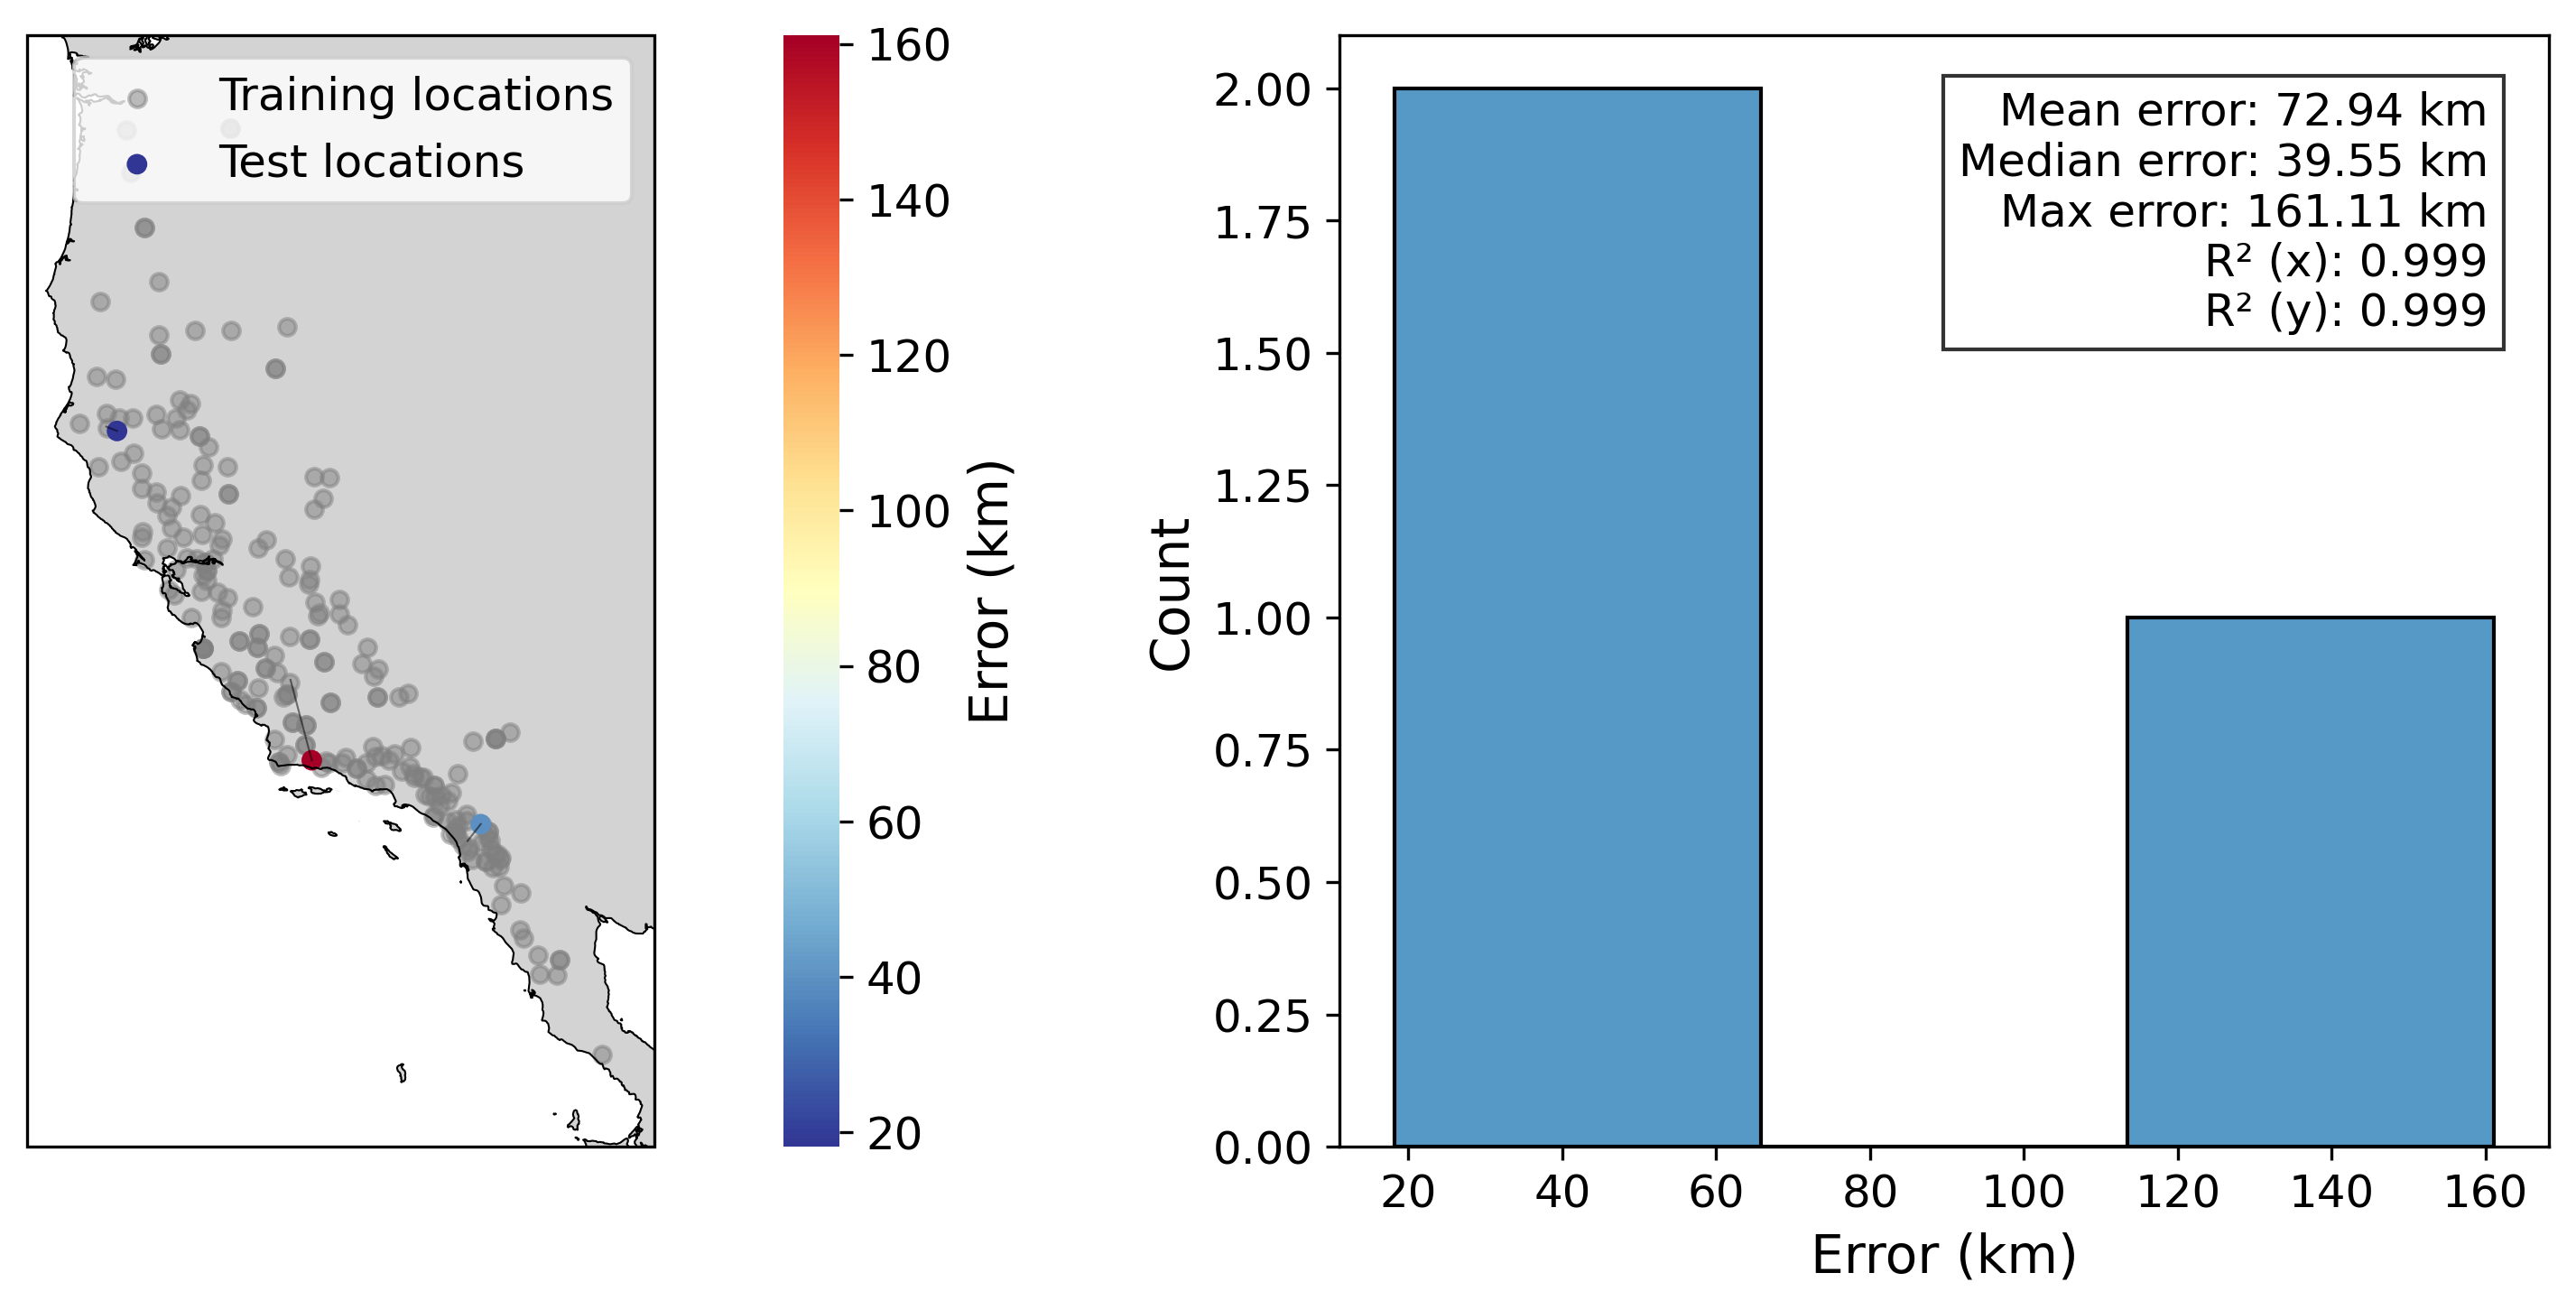

         19636131 function calls (19155314 primitive calls) in 55.414 seconds

   Ordered by: internal time
   List reduced from 7326 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1659   20.883    0.013   20.883    0.013 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_Execute}
      257    6.285    0.024    6.292    0.024 {built-in method posix.fork}
    10562    4.317    0.000    4.328    0.000 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_FastPathExecute}
      192    2.457    0.013    2.457    0.013 {built-in method time.sleep}
     5258    2.258    0.000    2.258    0.000 {method '_numpy_internal' of 'tensorflow.python.framework.ops.EagerTensor' objects}
     7966    0.596    0.000    0.596    0.000 {method 'copy' of 'numpy.ndarray' objects}
    11738    0.595    0.000    0.899    0.000 coords.py:109(xy)
        2    0.468    0.234    4.056    2.028 shapereader.py:196(__init__)
   446330    0.440    0.000  

In [3]:
%%prun -l 20
locator.train_holdout(
    genotypes=genotypes, samples=samples,
    k=3,
)
preds = locator.predict_holdout(return_df=True)

In [ ]:
locator

In [4]:
%%prun -l 20
ho_preds = locator.run_k_fold_holdouts(genotypes, samples, k=3, verbose=False, return_df=True)



Holdout split summary:
  Training samples: 123 (53.2%)
  Validation samples: 31 (13.4%)
  Holdout samples: 77 (33.3%)
  Total samples: 231
  Total SNPs: 100114
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5

Holdout split summary:
  Training samples: 123 (53.2%)
  Validation samples: 31 (13.4%)
  Holdout samples: 77 (33.3%)
  Total samples: 231
  Total SNPs: 100114
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5

Holdout split summary:
  Training samples: 123 (53.2%)
  Validation samples: 31 (13.4%)
  Holdout samples: 77 (33.3%)
  Total samples: 231
  Total SNPs: 100114
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5


Process LokyProcess-254:
Process LokyProcess-251:
Process LokyProcess-248:
Process LokyProcess-245:
Process LokyProcess-247:
Process LokyProcess-249:
Process LokyProcess-244:
Process LokyProcess-238:
Process LokyProcess-243:
Process LokyProcess-246:
Process LokyProcess-230:
Process LokyProcess-224:
Process LokyProcess-240:
Process LokyProcess-218:
Process LokyProcess-221:
Process LokyProcess-217:
Process LokyProcess-211:
Process LokyProcess-229:
Process LokyProcess-219:
Process LokyProcess-242:
Process LokyProcess-226:
Process LokyProcess-220:
Process LokyProcess-199:
Process LokyProcess-210:
Process LokyProcess-202:
Process LokyProcess-213:
Process LokyProcess-190:
Process LokyProcess-192:
Process LokyProcess-179:
Process LokyProcess-187:
Process LokyProcess-181:
Process LokyProcess-180:
Process LokyProcess-176:
Process LokyProcess-171:
Process LokyProcess-172:
Process LokyProcess-157:
Process LokyProcess-154:
Process LokyProcess-169:
Process LokyProcess-144:
Process LokyProcess-152:


KeyboardInterrupt: 

In [ ]:
ho_preds

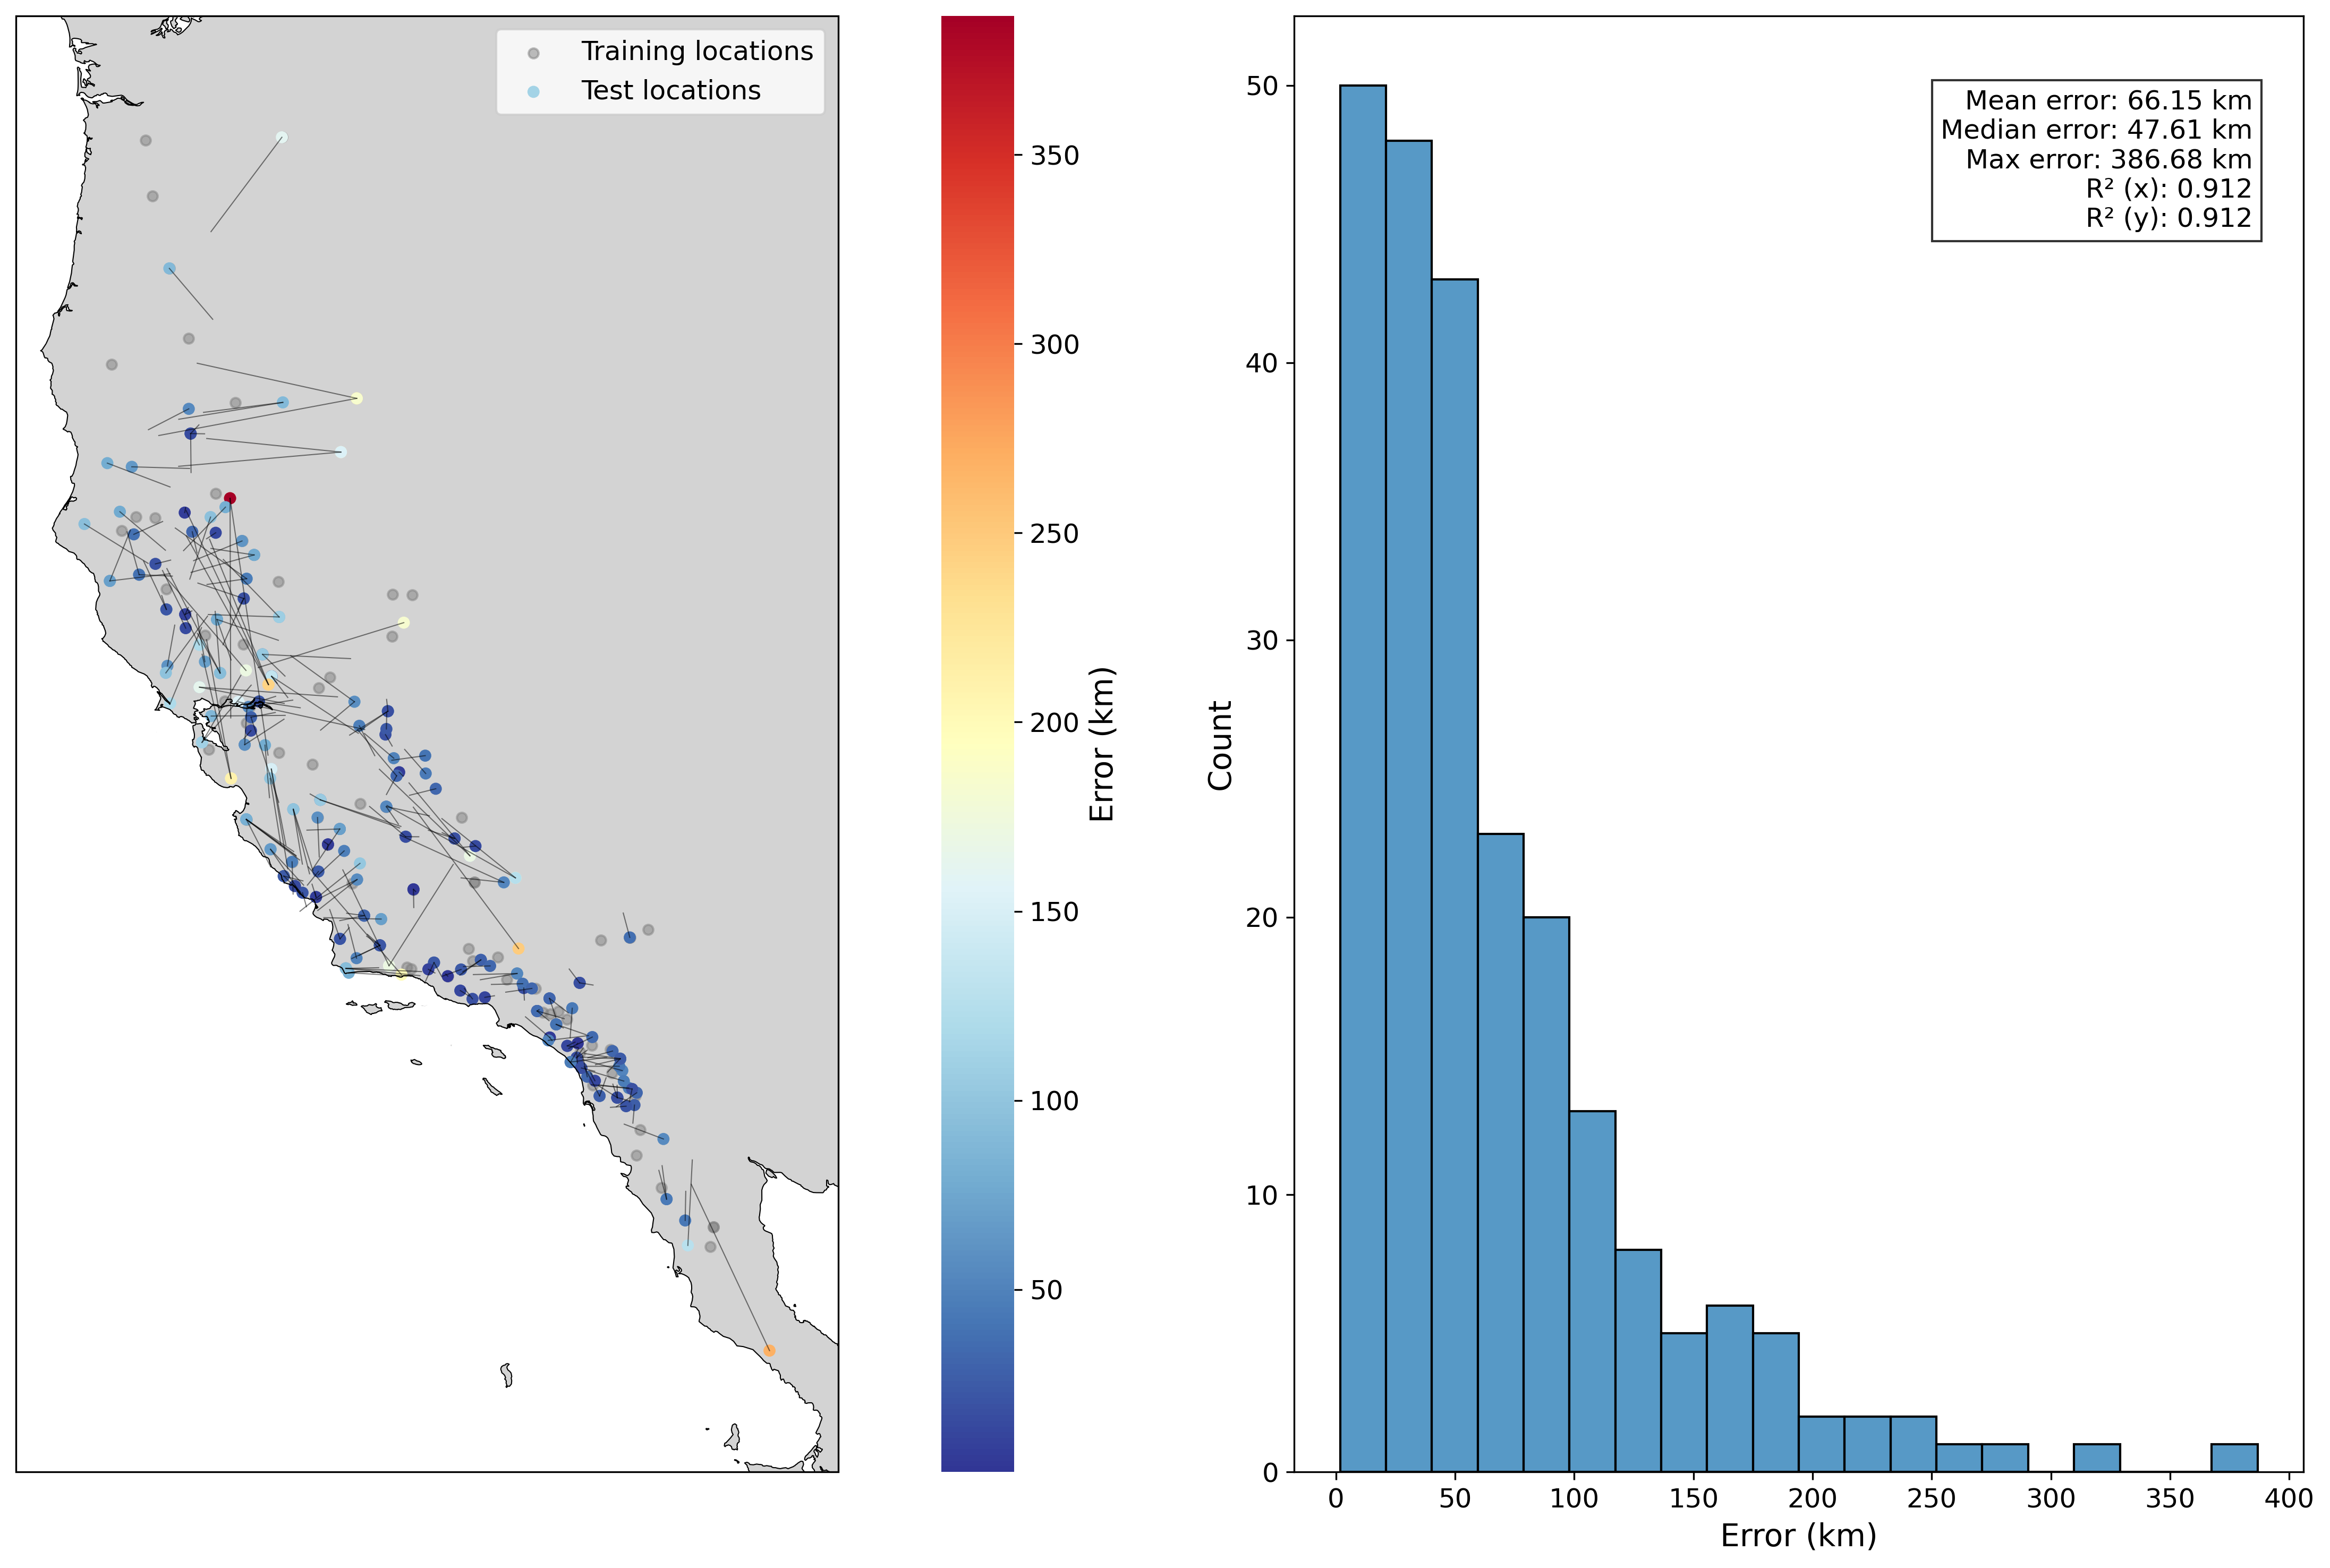

In [23]:
plot_error_summary(
    predictions=ho_preds,
    sample_data=coords_path,
    plot_map=True,
    include_training_locs=True,
)

In [ ]:
loo = locator.run_leave_one_out(genotypes, samples, return_df=True)

In [ ]:
plot_error_summary(
    predictions=loo,
    sample_data=coords_path,
    plot_map=True,
    include_training_locs=True,
)

In [3]:
results = simple_parallel_leave_one_out(
    locator=locator,
    genotypes=genotypes,
    samples=samples,
    gpu_ids=[1, 2],
    verbose=True
)
    

Running leave-one-out CV for 231 samples in parallel on GPUs: [1, 2]
Note: Processing many samples. Using batch processing for efficiency.

Processing samples 1-4 of 231 in parallel on 2 GPUs...


I0000 00:00:1751313761.682597 2370065 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 69720 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
I0000 00:00:1751313762.976807 2370066 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 69298 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
I0000 00:00:1751313763.804818 2370064 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 67831 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
I0000 00:00:1751313763.908425 2370063 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 67427 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
I0000 00:00:1751313768.895648 2372497 cuda_dnn.cc:527] Loaded cu

KeyboardInterrupt: 